In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

from pyBigKinds.preprocessing import keyword_dataframe

import math
import warnings
warnings.filterwarnings("ignore")

plt.rcParams["font.family"] = "NanumGothic"
plt.rcParams['axes.unicode_minus'] = False

pd.options.display.float_format = '{:.0f}'.format

In [2]:
import os
os.chdir("../../model/depression")

topic_df = pd.read_excel("topic_name_depression.xlsx", engine="openpyxl")
topic_df = topic_df[["Group", "Topic"]]

all_df = pd.read_excel("df_depression.xlsx", engine="openpyxl")
all_df.columns = ["name", "press","keywords", "year"]

doc_df = pd.read_excel("doc_topics_depression.xlsx", engine="openpyxl")

analysis_df = pd.merge(doc_df, all_df[["name", "press", "year"]], how = "left")
analysis_df = analysis_df.drop_duplicates(["name", "Document", "press"])

df = pd.merge(analysis_df, topic_df, on='Topic')
df["year_range"] = df["year"].apply(lambda x: math.floor(x/10)*10)

In [3]:
conditions = [
    (df["press"].str.contains("조선일보")),
    (df["press"].str.contains("동아일보")),
    (df["press"].str.contains("한겨레")),
    (df["press"].str.contains("경향신문")),
    (df["press"].str.contains("한국일보")),
    (df["press"].str.contains("서울신문")),
]
choices = ["보수", "보수", "진보", "진보", "중도", "중도"]

df["Partizanship"] = np.select(conditions, choices, default='Other')

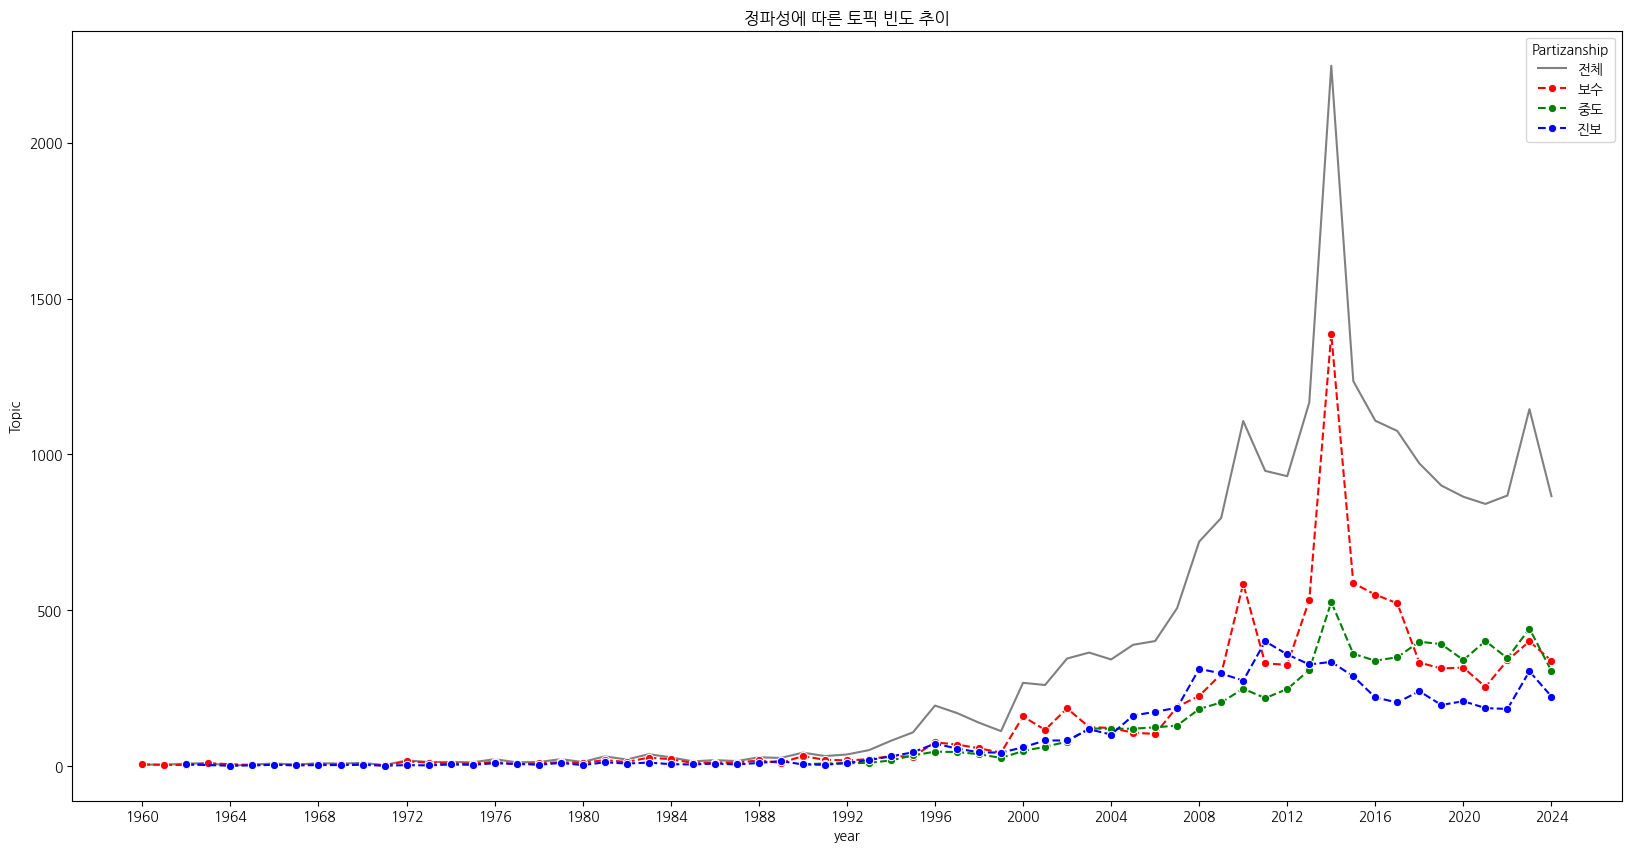

In [4]:
tmp1 = df.groupby("year").count()
tmp2 = df.groupby(["year", "Partizanship"]).count().sort_values("Topic", ascending=False).reset_index()

plt.figure(figsize=(20, 10))

sns.lineplot(data=tmp1, x = "year", y = "Topic", label="전체", color="gray", linestyle='-')
sns.lineplot(data=tmp2, x = "year", y = "Topic", hue="Partizanship", palette=["red", "green", "blue"], linestyle='--',marker='o')

plt.xticks([i for i in range(1960,2025,4)])

plt.title("정파성에 따른 토픽 빈도 추이")
plt.show()

In [5]:
df[df["Group"].str.contains("사건사고")|df["Group"].str.contains("범죄")| df["Group"].str.contains("폭력")|
         df["Group"].str.contains("경찰")].groupby('Group').count()

,name,Year,Document,Topic,press,year,year_range,Partizanship
Group,,,,,,,,
우울증 환자의 범죄,330,330,330,330,330,330,330,330
우울증과 가정폭력/살인,297,297,297,297,297,297,297,297
우울증과 경찰 수사 관련 이슈,915,915,915,915,915,915,915,915
우울증과 범죄,99,99,99,99,99,99,99,99
우울증과 연예계 사건사고,279,279,279,279,279,279,279,279
우울증과 온라인 커뮤니티 관련 사건사고,183,183,183,183,183,183,183,183
우울증과 폭력/성폭력 사건,669,669,669,669,669,669,669,669


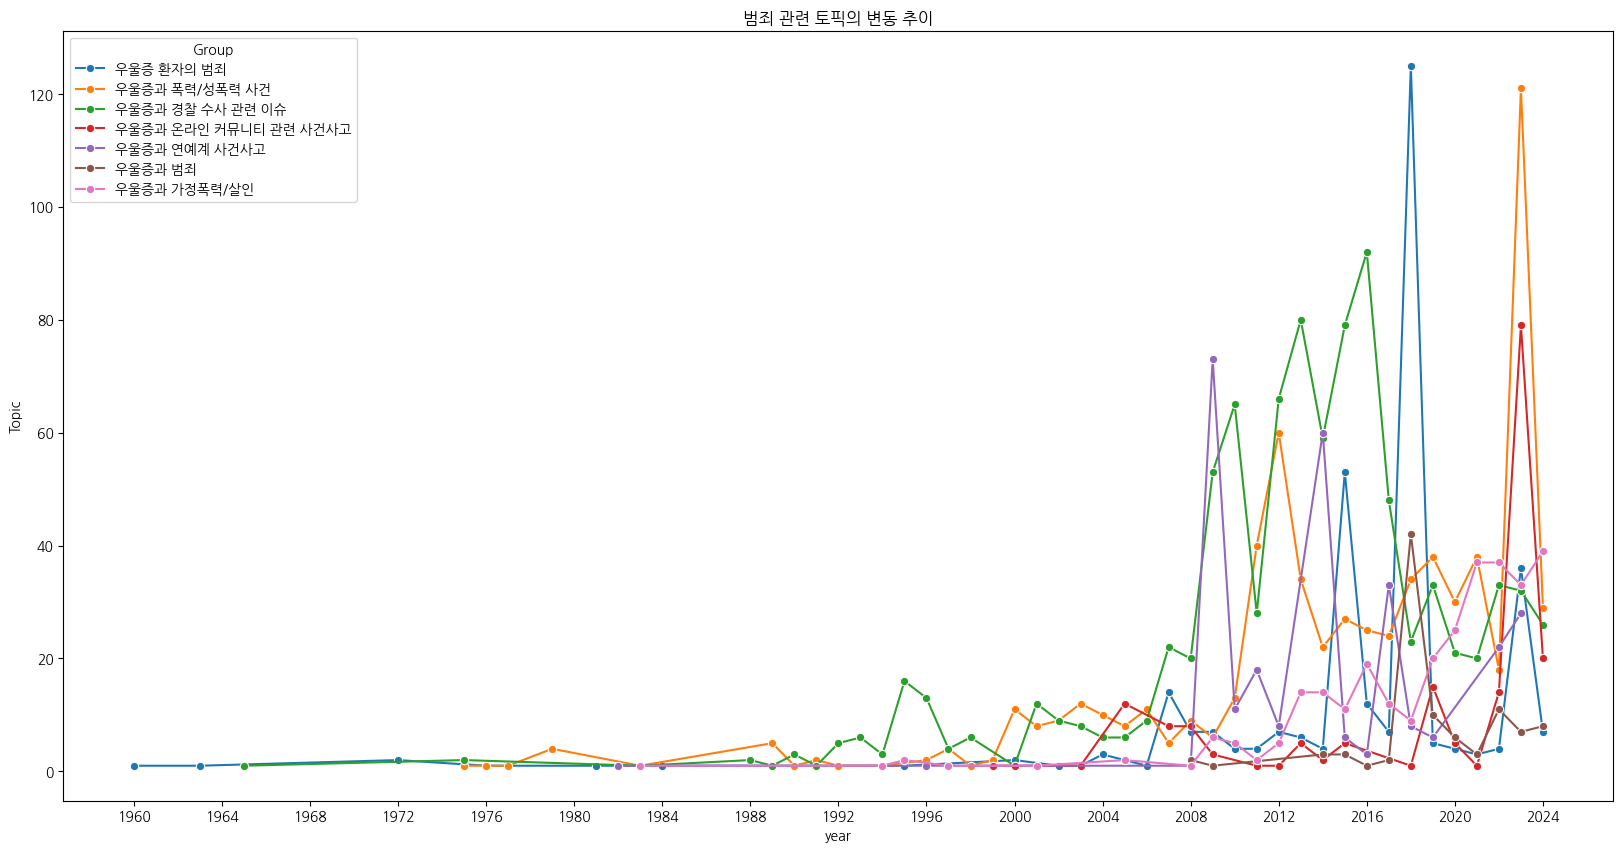

In [6]:
tmp = df[df["Group"].str.contains("사건사고")|df["Group"].str.contains("범죄")| df["Group"].str.contains("폭력")|
         df["Group"].str.contains("경찰")].groupby(["year", "Group"]).count().sort_values("Topic", ascending=False).reset_index()

plt.figure(figsize=(20, 10))

sns.lineplot(data=tmp, x = "year", y = "Topic", hue = "Group", linestyle='-',marker='o')

plt.xticks([i for i in range(1960,2025,4)])

plt.title("범죄 관련 토픽의 변동 추이")
plt.show()

In [7]:
tmp1 = df[df["Partizanship"]=="진보"].groupby("Group").count().sort_values("name", ascending=False).reset_index()
tmp2 = df[df["Partizanship"]=="보수"].groupby("Group").count().sort_values("name", ascending=False).reset_index()
tmp3 = df[df["Partizanship"]=="중도"].groupby("Group").count().sort_values("name", ascending=False).reset_index()

tmp_merged = pd.concat([tmp1[["Group", "name"]], tmp2[["Group", "name"]], tmp3[["Group", "name"]]], axis=1)

tmp_merged.columns = ["진보 상위 토픽", "진보 토픽 빈도", "보수 상위 토픽", "보수 토픽 빈도", "중도 상위 토픽", "중도 토픽 빈도"]

tmp_merged.head(10).style.set_caption("정파성 별 우울증 토픽 기사 빈도")

,진보 상위 토픽,진보 토픽 빈도,보수 상위 토픽,보수 토픽 빈도,중도 상위 토픽,중도 토픽 빈도
0,우울증과 노동자 관련 이슈,422.000000,우울증과 예술인,920,우울증을 유발하는 질환,489.000000
1,우울증과 예술 작품,411.000000,우울증을 유발하는 질환,594,우울증과 예술인,405.000000
2,우울증을 유발하는 질환,361.000000,우울증과 의약물,414,우울증과 사회적 트라우마,285.000000
3,우울증과 예술인,322.000000,우울증과 경찰 수사 관련 이슈,404,우울증과 자연/음식/문화,281.000000
4,우울증과 사회적 트라우마,295.000000,우울증과 연예계 관련 소식,396,우울증과 경찰 수사 관련 이슈,274.000000
5,정치/경제 정책과 우울증,260.000000,우울증과 스포츠 선수,369,우울증과 예술 작품,260.000000
6,우울증과 자연/음식/문화,256.000000,우울증과 예술 작품,345,우울증과 의약물,240.000000
7,우울증과 폭력/성폭력 사건,243.000000,정치/경제 정책과 우울증,278,우울증과 폭력/성폭력 사건,230.000000
8,우울증과 경찰 수사 관련 이슈,237.000000,우울증과 연예대상 관련 소식,261,우울증과 자살 예방,221.000000
9,우울증과 의약물,217.000000,우울증과 축구 선수 관련 이슈,225,우울증과 호르몬 이슈,192.000000


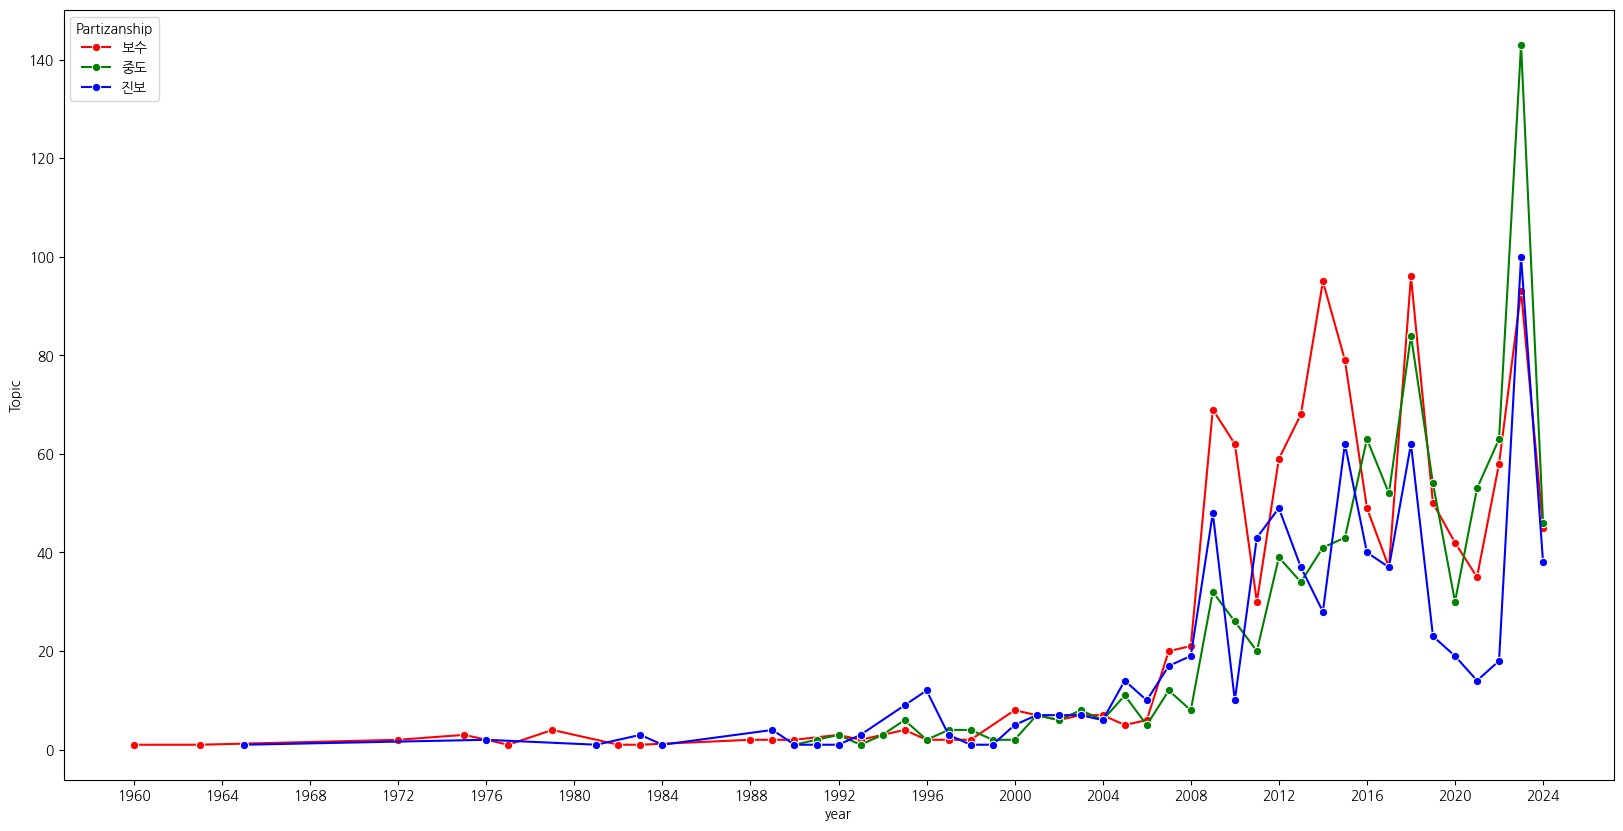

In [ ]:
tmp = df[df["Group"].str.contains("사건사고")|df["Group"].str.contains("범죄")|df["Group"].str.contains("폭력")|
         df["Group"].str.contains("경찰")].groupby(["year", "Partizanship"]).count().reset_index().sort_values("Topic", ascending=False)

plt.figure(figsize=(20, 10))

legend_order = ["보수", "중도", "진보"]

sns.lineplot(data = tmp, x = "year", y = "Topic", hue="Partizanship",  hue_order = legend_order,
             palette=["red", "green", "blue"], linestyle='-',marker='o')

plt.xticks([i for i in range(1960,2025,4)])

plt.show()

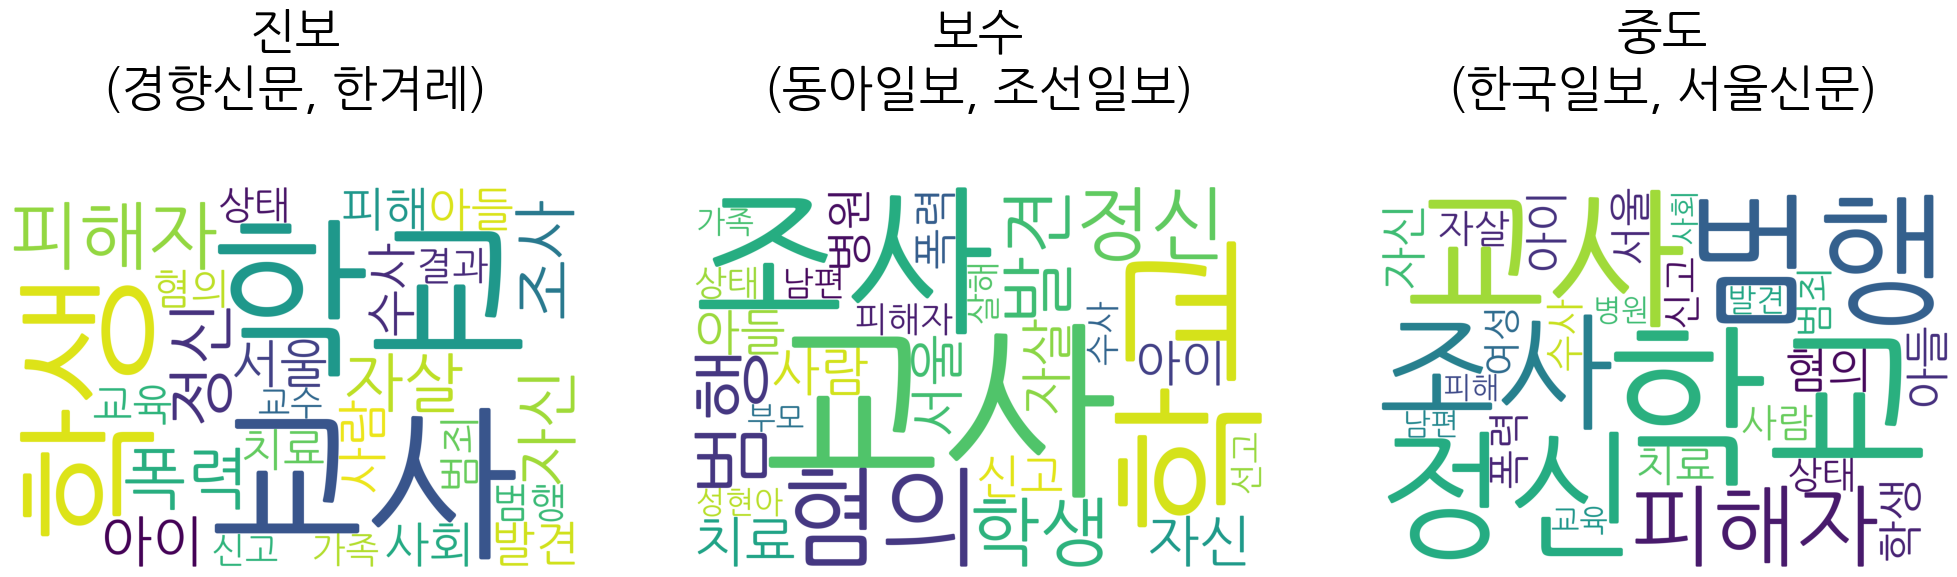

In [ ]:
category = df[df["Group"].str.contains("사건사고")|df["Group"].str.contains("범죄")|
              df["Group"].str.contains("폭력")|df["Group"].str.contains("경찰")]
category["키워드"] = category["Document"]

liberal = keyword_dataframe(category[category["Partizanship"] == "진보"])
conservative = keyword_dataframe(category[category["Partizanship"] == "보수"])
neutral = keyword_dataframe(category[category["Partizanship"] == "중도"])

wc = WordCloud(width = 3000, height = 2000, random_state=100,
              background_color="white", font_path="NanumGothic")

fig, ax = plt.subplots(1, 3, figsize=(25, 15))

dataframe = [liberal, conservative, neutral]
partizanship = ["진보", "보수", "중도"]
media_list = [", ".join(category[category["Partizanship"] == p]["press"].unique()) for p in ["진보", "보수", "중도"]]

for i in range(len(dataframe)):
    keywords = dataframe[i][:30].set_index("단어").to_dict()["빈도"]
    keywords.pop("경찰")
    keywords.pop("우울증")
    keywords.pop("사건")
    
    ax[i].imshow(wc.generate_from_frequencies(keywords))
    ax[i].set_title(f"{partizanship[i]}\n({media_list[i]})", fontsize=35, pad=60)
    ax[i].axis("off")
plt.show()